<a href="https://colab.research.google.com/github/philpos17/dhbw-kartoffel-sortierung/blob/main/code/colab/potato_stage2_cls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

%pip install -q roboflow ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.9/112.6 GB disk)


In [ ]:
from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("ms-workspace-m1gci").project("potato-sorting-on-conveyor")
dataset = project.version(8).download("yolov8")

print(f"Datensatz erfolgreich geladen: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Potato-Sorting-on-Conveyor-8 in yolov8:: 100%|██████████| 4579/4579 [00:00<00:00, 6166.81it/s]

Datensatz erfolgreich geladen: /content/Potato-Sorting-on-Conveyor-8


In [ ]:
import os
import cv2
import yaml
import shutil
from pathlib import Path

# Pfade definieren
dataset_path = Path(dataset.location)
out_dir = Path("/content/potato-cls")

# Alten Ordner löschen falls vorhanden
if out_dir.exists():
    shutil.rmtree(out_dir)

# data.yaml lesen um Klassen-IDs zu bekommen
with open(dataset_path / "data.yaml", 'r') as f:
    data_yaml = yaml.safe_load(f)

names = data_yaml.get('names', [])
if isinstance(names, dict):
    class_names = {v: k for k, v in names.items()}
else:
    class_names = {name: i for i, name in enumerate(names)}

potato_id = class_names.get('potato', 2)
bad_id = class_names.get('bad', 0)
cut_id = class_names.get('cut', 1)
defect_ids = [bad_id, cut_id]

def check_intersection(box1, box2):
    # box: [x_center, y_center, width, height] in relativen Koordinaten
    b1_x1 = box1[0] - box1[2]/2
    b1_x2 = box1[0] + box1[2]/2
    b1_y1 = box1[1] - box1[3]/2
    b1_y2 = box1[1] + box1[3]/2

    b2_x1 = box2[0] - box2[2]/2
    b2_x2 = box2[0] + box2[2]/2
    b2_y1 = box2[1] - box2[3]/2
    b2_y2 = box2[1] + box2[3]/2

    # Überschneidung testen
    if b1_x1 > b2_x2 or b2_x1 > b1_x2: return False
    if b1_y1 > b2_y2 or b2_y1 > b1_y2: return False
    return True

healthy_count = 0
bad_count = 0

for split in ['train', 'valid', 'test']:
    split_dir = dataset_path / split
    if not split_dir.exists(): continue

    (out_dir / split / 'healthy').mkdir(parents=True, exist_ok=True)
    (out_dir / split / 'bad').mkdir(parents=True, exist_ok=True)

    for img_path in (split_dir / 'images').glob("*.jpg"):
        label_path = split_dir / 'labels' / (img_path.stem + ".txt")
        if not label_path.exists(): continue

        img = cv2.imread(str(img_path))
        if img is None: continue
        h, w, _ = img.shape

        with open(label_path, 'r') as f:
            lines = f.readlines()

        boxes = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls_id = int(parts[0])
            box = [float(x) for x in parts[1:5]]
            boxes.append((cls_id, box))

        potato_boxes = [b for b in boxes if b[0] == potato_id]
        defect_boxes = [b for b in boxes if b[0] in defect_ids]

        for i, (_, p_box) in enumerate(potato_boxes):
            is_bad = False
            for _, d_box in defect_boxes:
                if check_intersection(p_box, d_box):
                    is_bad = True
                    break

            # Ausschneiden (Crop)
            px_c, py_c, pw, ph = p_box
            x1 = max(0, int((px_c - pw/2) * w))
            y1 = max(0, int((py_c - ph/2) * h))
            x2 = min(w, int((px_c + pw/2) * w))
            y2 = min(h, int((py_c + ph/2) * h))

            crop = img[y1:y2, x1:x2]
            if crop.size == 0: continue

            if is_bad:
                label = 'bad'
                bad_count += 1
            else:
                label = 'healthy'
                healthy_count += 1

            save_path = out_dir / split / label / f"{img_path.stem}_crop_{i}.jpg"
            cv2.imwrite(str(save_path), crop)

print(f"Klassifikations-Datensatz erfolgreich erstellt in {out_dir}")
print(f"Gesunde Kartoffeln (healthy): {healthy_count}")
print(f"Kranke Kartoffeln (bad): {bad_count}")

Klassifikations-Datensatz erfolgreich erstellt in /content/potato-cls
Gesunde Kartoffeln (healthy): 41878
Kranke Kartoffeln (bad): 1386


In [ ]:
from ultralytics import YOLO

# YOLO11s Klassifikations-Modell laden
model = YOLO('yolo11s-cls.pt')

# Modell auf dem neu erstellten Datensatz trainieren
# imgsz=224 ist Standard für Klassifikation, kann man auch auf 128 oder 256 setzen
results = model.train(data='/content/potato-cls', epochs=30, imgsz=224, batch=32, plots=True)

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/potato-cls, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, 

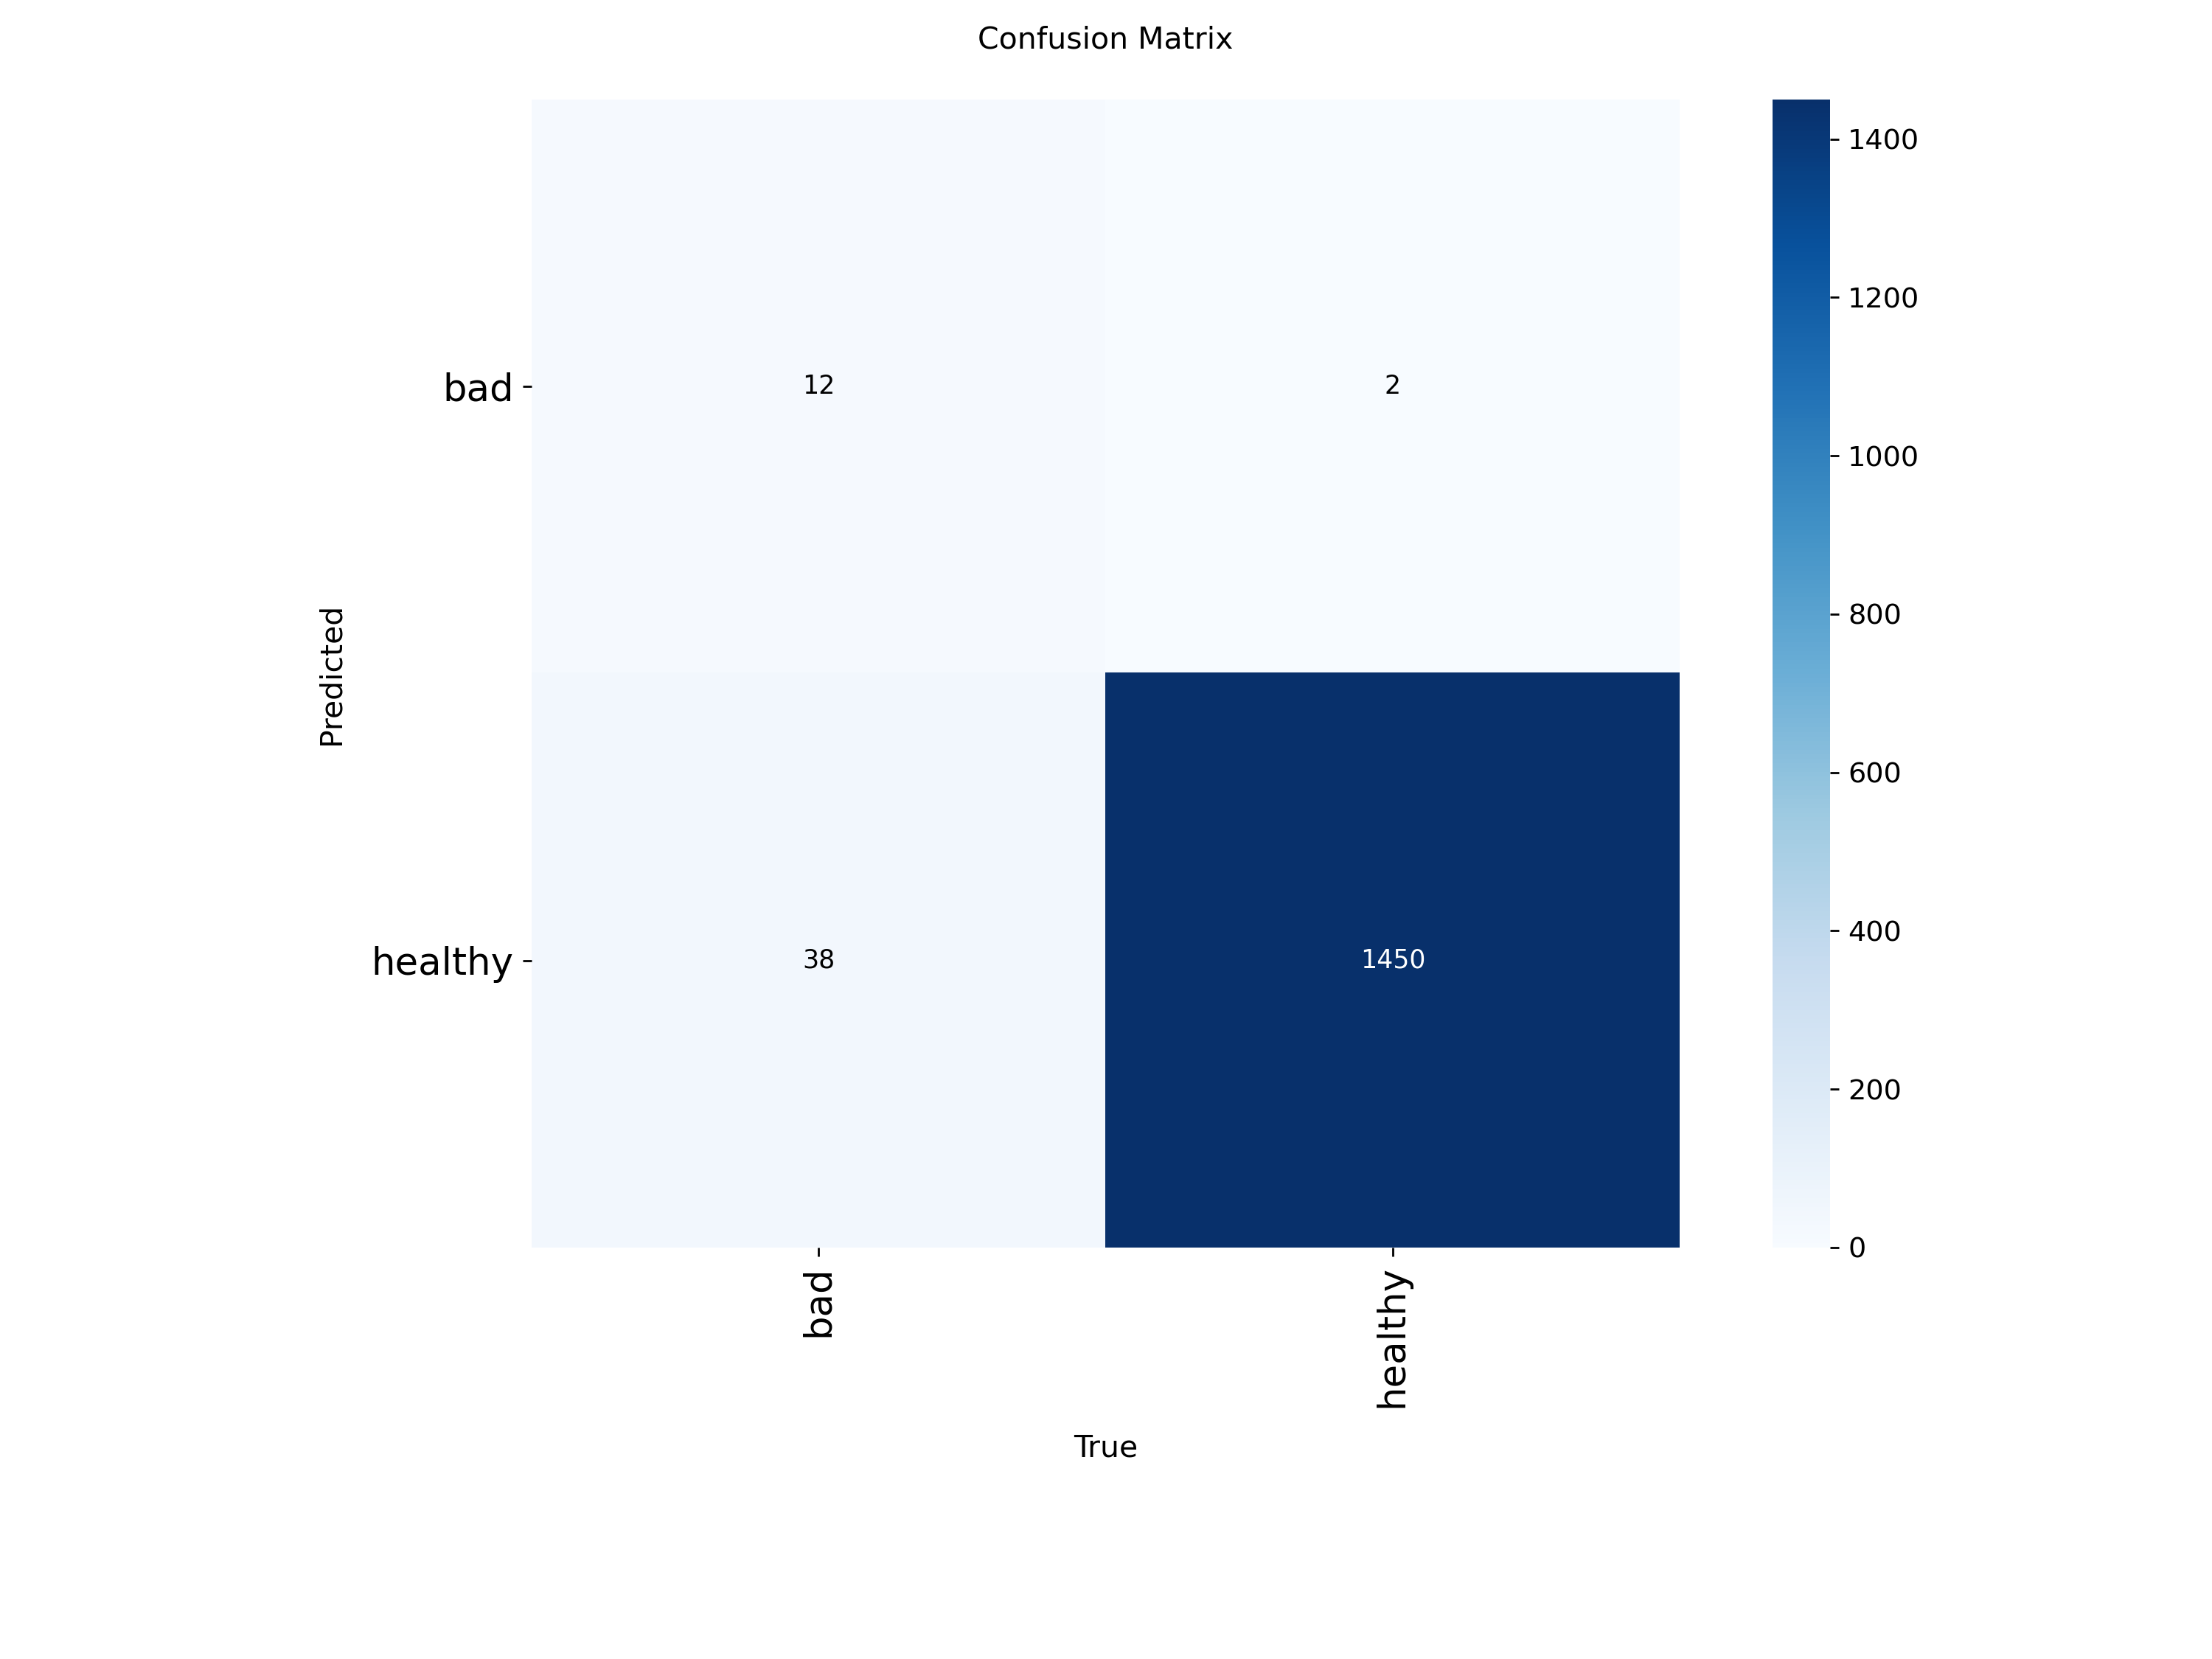

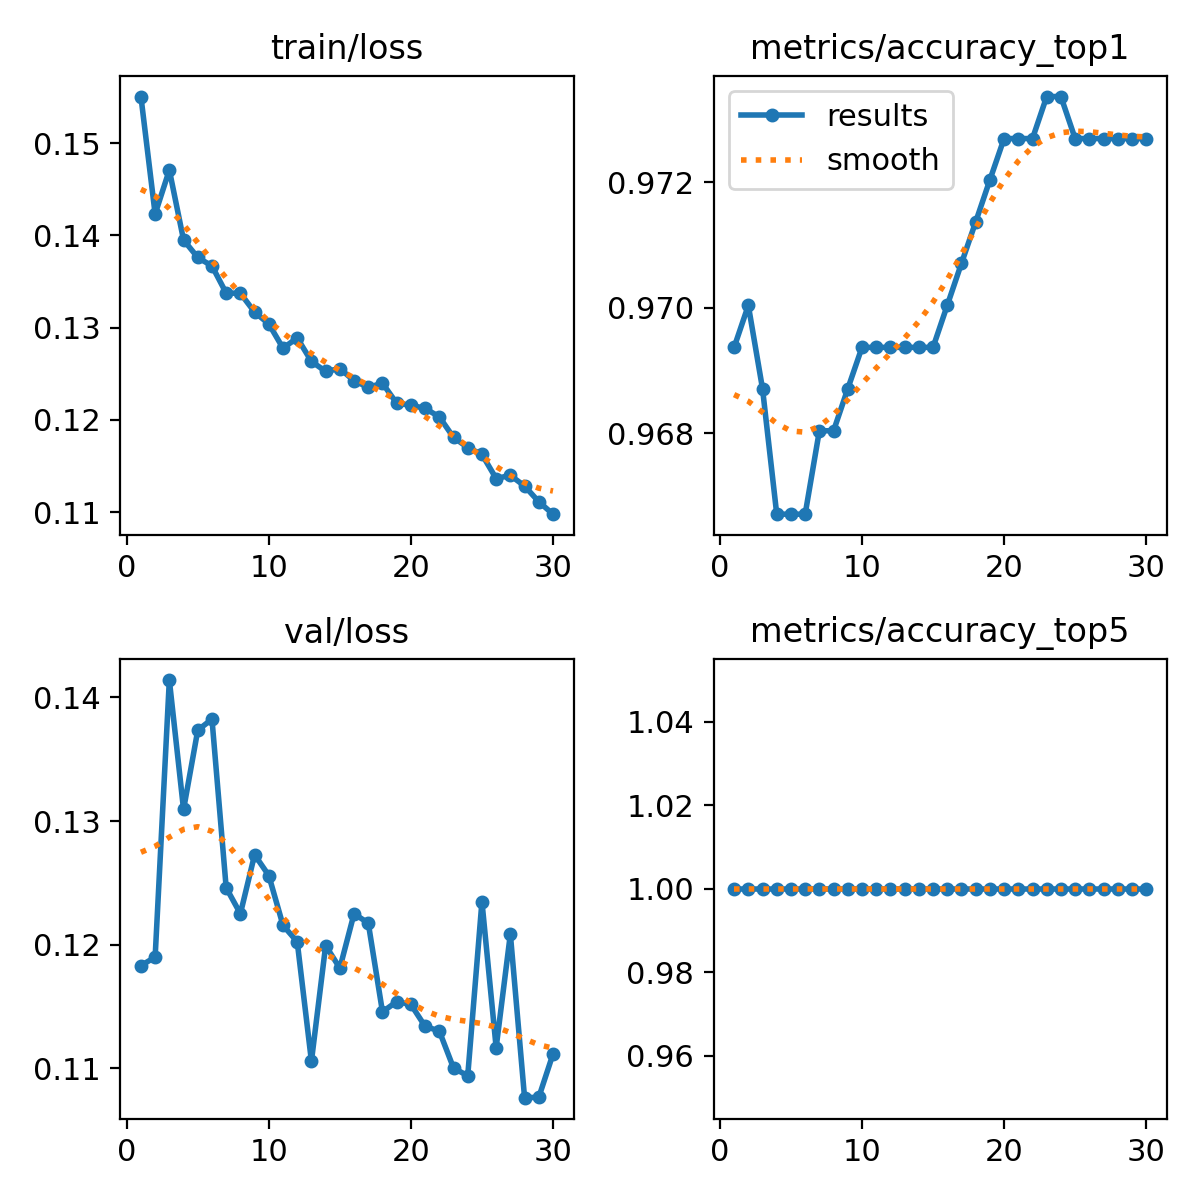

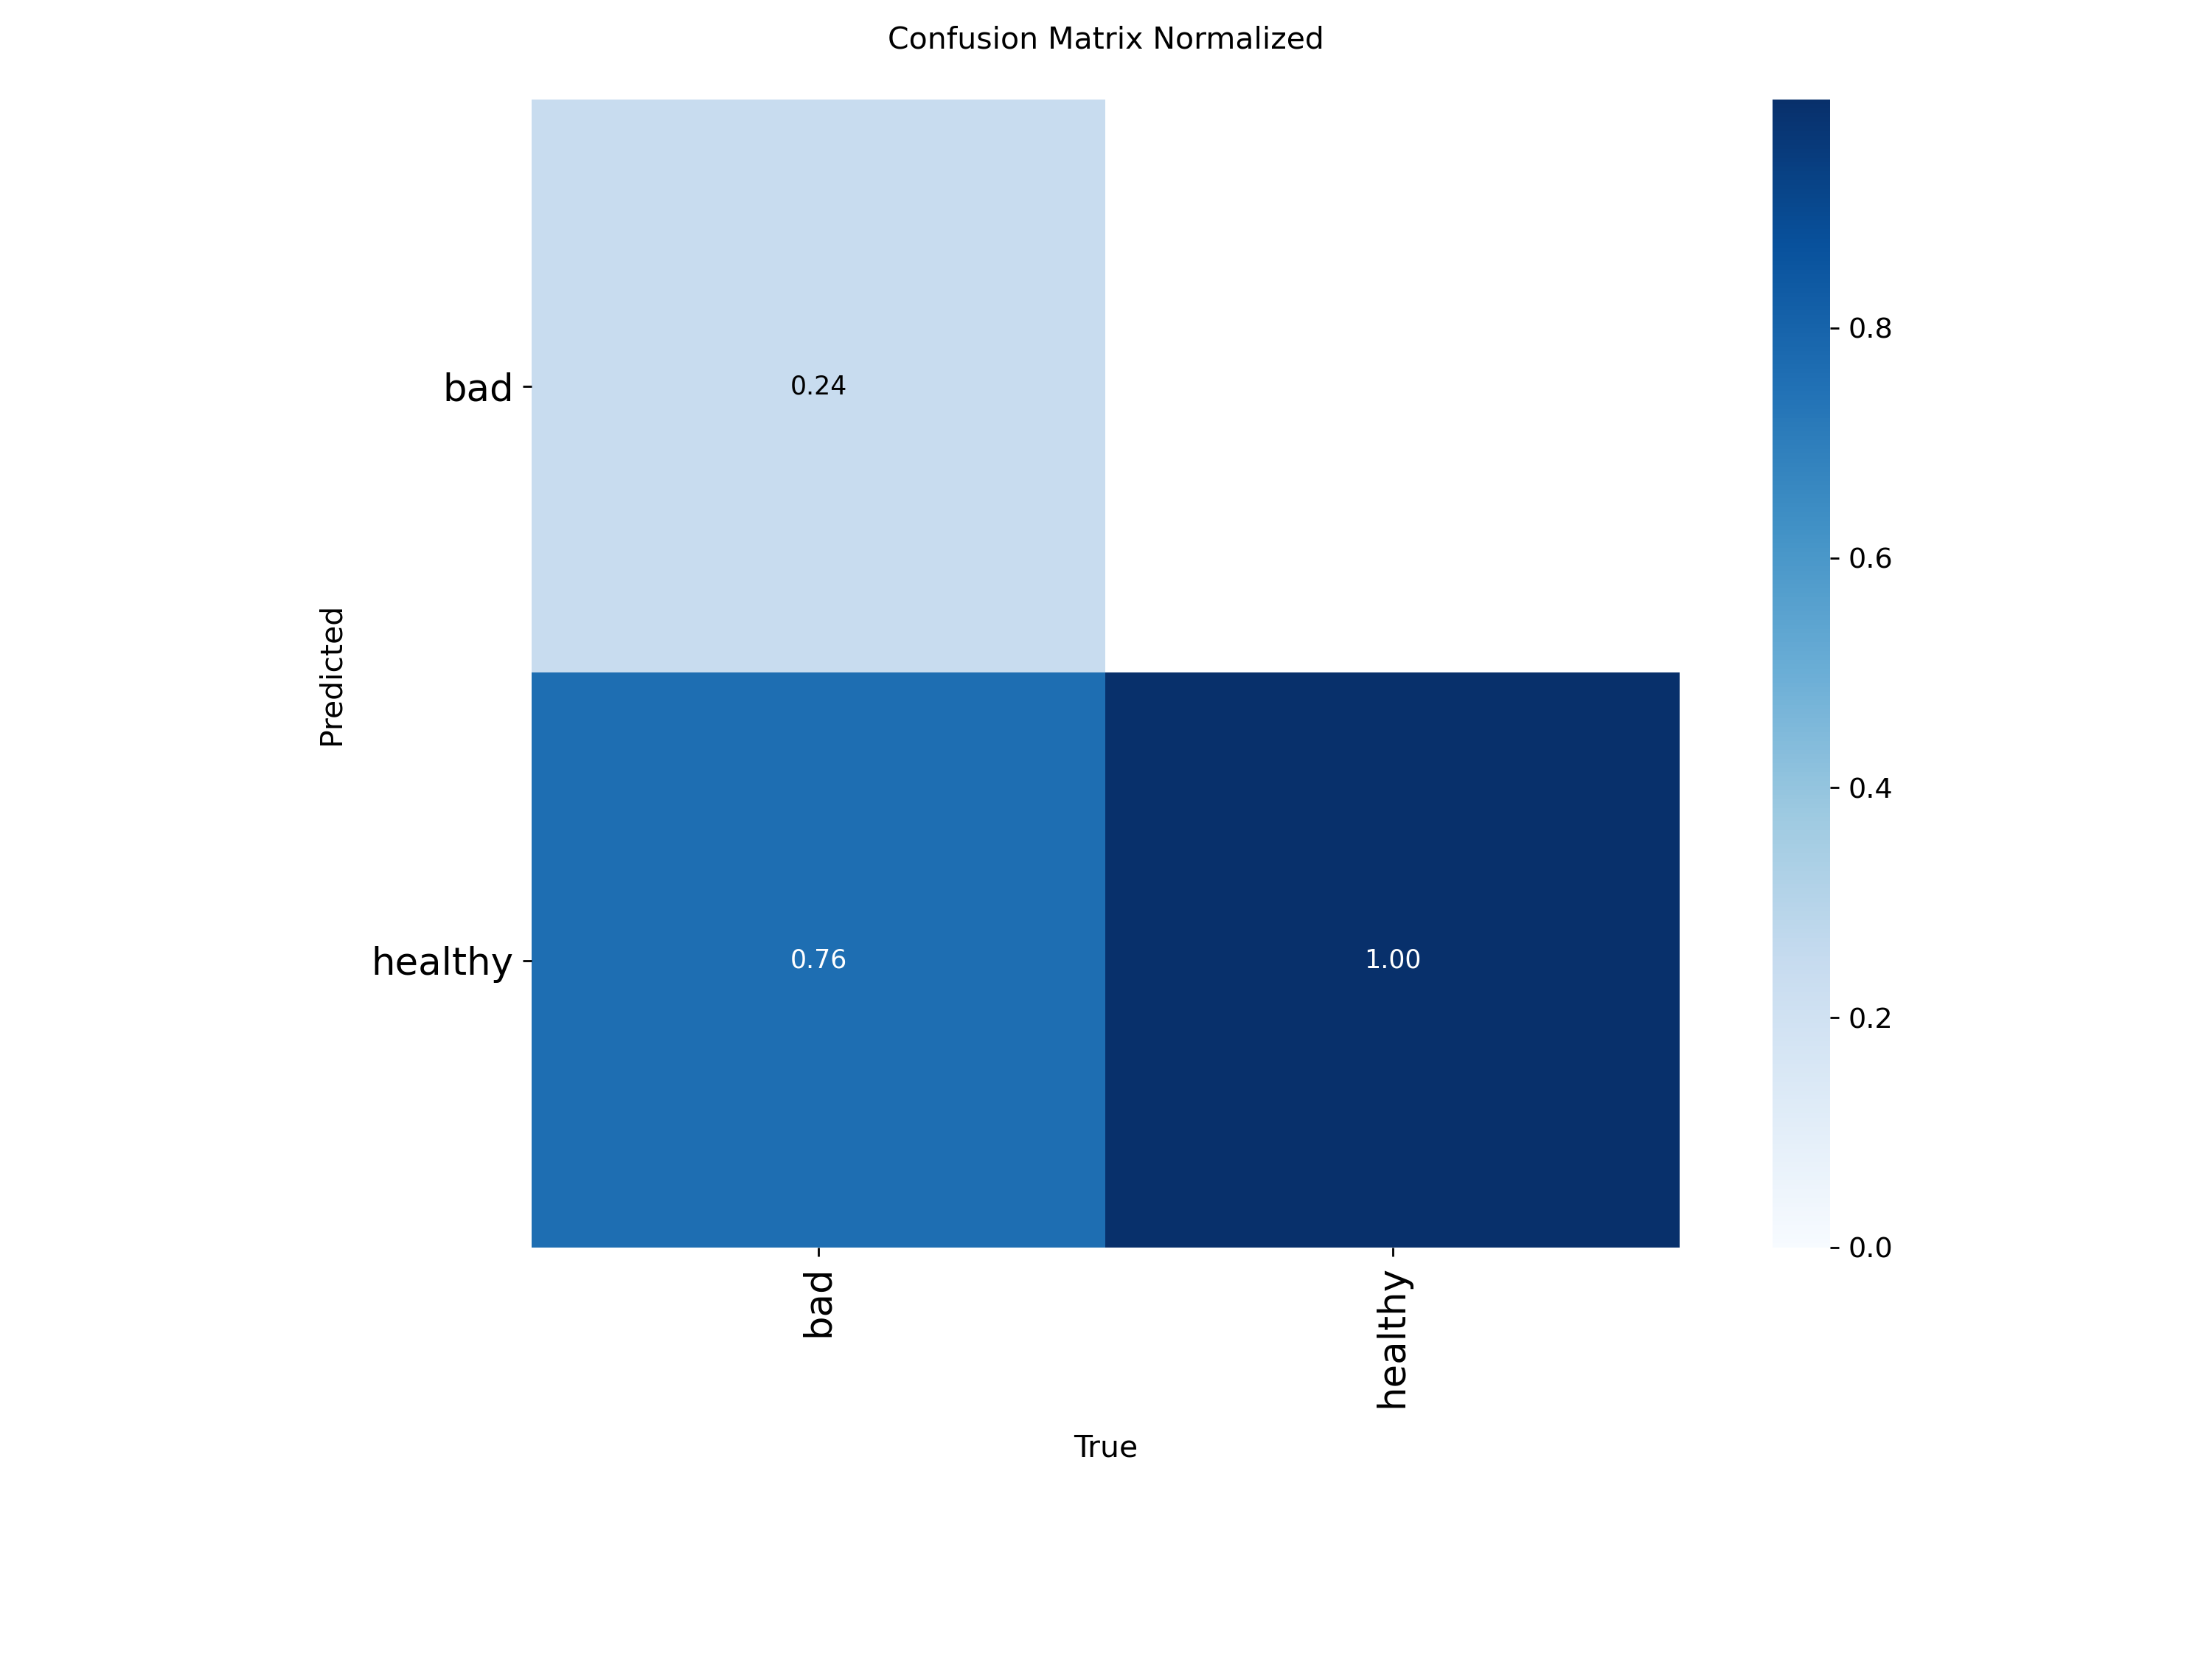

Training abgeschlossen. Checke die Confusion Matrix für die Genauigkeit von 'bad' vs 'healthy'.


In [5]:
# Ergebnisse anzeigen (Confusion Matrix etc.)
from IPython.display import Image, display
import glob

for img_path in glob.glob('runs/classify/train/*.png'):
    display(Image(filename=img_path))

print("Training abgeschlossen. Checke die Confusion Matrix für die Genauigkeit von 'bad' vs 'healthy'.")

In [6]:
import shutil
from google.colab import files

# Define the path to the best model's results folder
BEST_DIR = '/content/runs/classify/train'
# Define a label for the best model iteration
BEST_LABEL = 'best_classification_model'

# 2. Den gewünschten Namen und Speicherort für die ZIP-Datei festlegen
# Hinweis: shutil hängt das '.zip' automatisch an diesen Namen an
zip_file_name = f'/content/Kartoffel_Ergebnisse_Iteration4_{BEST_LABEL}'

# 3. Den gesamten Ordner packen
print("Ordner wird gezippt... Bitte warten.")
shutil.make_archive(zip_file_name, 'zip', BEST_DIR)

# 4. Die fertige ZIP-Datei auf dein MacBook herunterladen
print("Download startet gleich!")
files.download(zip_file_name + '.zip')

Ordner wird gezippt... Bitte warten.
Download startet gleich!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>